In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
file_path = Path.cwd()
file_name = "guide.xlsx"

guide = pd.read_excel(file_path / file_name)
guide.columns = guide.columns.str.strip().str.lower()

In [3]:
guide = guide[["field name", "code/format", "label"]]
guide = guide.dropna(subset=["code/format"])

In [4]:
mappings = {}

for field in guide["field name"].unique():
    subset = guide[guide["field name"] == field]
    
    # create dictionary: code → label
    mapping = dict(zip(subset["code/format"], subset["label"]))
    
    mappings[field] = mapping

In [5]:
file_name = "collision.csv"
df = pd.read_csv(file_path / file_name)

C:\Users\komet\AppData\Local\Temp\ipykernel_38696\1895461725.py:2: DtypeWarning: Columns (0: collision_index, 1: collision_ref_no) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path / file_name)


In [6]:
df.isna().sum()

collision_index                                     0
collision_year                                      0
collision_ref_no                                    0
location_easting_osgr                               1
location_northing_osgr                              1
longitude                                           1
latitude                                            1
police_force                                        0
collision_severity                                  0
number_of_vehicles                                  0
number_of_casualties                                0
date                                                0
day_of_week                                         0
time                                                0
local_authority_district                            0
local_authority_ons_district                        0
local_authority_highway                             0
local_authority_highway_current                     3
first_road_class            

In [7]:
num_columns= ["police_force","collision_severity","number_of_vehicles","number_of_casualties","day_of_week","local_authority_district", "first_road_class", "road_type", "speed_limit", "junction_detail_historic", "junction_detail", "junction_control", "second_road_class","second_road_number", "pedestrian_crossing_human_control_historic", "pedestrian_crossing_physical_facilities_historic", "pedestrian_crossing", "light_conditions", "weather_conditions" , "road_surface_conditions", "special_conditions_at_site", "urban_or_rural_area", "did_police_officer_attend_scene_of_accident", "trunk_road_flag","enhanced_severity_collision","collision_injury_based", "collision_adjusted_severity_serious", "collision_adjusted_severity_slight" ]

In [8]:
df[num_columns] = df[num_columns].apply(
    pd.to_numeric, errors="coerce"
)

In [9]:
guide["code/format"] = pd.to_numeric(guide["code/format"], errors="coerce")

In [10]:
df.loc[
    (df["first_road_number"] < 1) | (df["first_road_number"] > 9999),
    "first_road_number"
]= np.nan

df.loc[
    (df["second_road_number"] < 1) | (df["second_road_number"] > 9999),
    "second_road_number"
]= np.nan



In [11]:
df["collision_severity"] = df["collision_severity"].map(mappings["collision_severity"])
df["day_of_week"] = df["day_of_week"].map(mappings["day_of_week"])
df["police_force"] = df["police_force"].map(mappings["police_force"])
df["enhanced_severity_collision"] = df["enhanced_severity_collision"].map(mappings["enhanced_collision_severity"])
df["local_authority_district"] = df["local_authority_district"].map(mappings["local_authority_district"])
df["local_authority_highway"] = df["local_authority_highway"].map(mappings["local_authority_highway"])
df["first_road_class"] = df["first_road_class"].map(mappings["first_road_class"])
df["road_type"] = df["road_type"].map(mappings["road_type"])
df["junction_detail_historic"] = df["junction_detail_historic"].map(mappings["junction_detail_historic"])
df["junction_detail"] = df["junction_detail"].map(mappings["junction_detail"])
df["junction_control"] = df["junction_control"].map(mappings["junction_control"])
df["second_road_class"] = df["second_road_class"].map(mappings["second_road_class"])
df["pedestrian_crossing_human_control_historic"] = df["pedestrian_crossing_human_control_historic"].map(mappings["pedestrian_crossing_human_control_historic"])
df["pedestrian_crossing"] = df["pedestrian_crossing"].map(mappings["pedestrian_crossing"])
df["light_conditions"] = df["light_conditions"].map(mappings["light_conditions"])
df["weather_conditions"] = df["weather_conditions"].map(mappings["weather_conditions"])
df["road_surface_conditions"] = df["road_surface_conditions"].map(mappings["road_surface_conditions"])
df["special_conditions_at_site"] = df["special_conditions_at_site"].map(mappings["special_conditions_at_site"])
df["carriageway_hazards_historic"] = df["carriageway_hazards_historic"].map(mappings["carriageway_hazards_historic"])
df["carriageway_hazards"] = df["carriageway_hazards"].map(mappings["carriageway_hazards"])
df["urban_or_rural_area"] = df["urban_or_rural_area"].map(mappings["urban_or_rural_area"])
df["did_police_officer_attend_scene_of_accident"] = df["did_police_officer_attend_scene_of_accident"].map(mappings["did_police_officer_attend_scene_of_accident"])
df["trunk_road_flag"] = df["trunk_road_flag"].map(mappings["trunk_road_flag"])
df["collision_injury_based"] = df["collision_injury_based"].map(mappings["collision_injury_based"])

In [12]:
threshold = 0.4
df = df.loc[:, df.isnull().mean() < threshold]

In [13]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_pct = (missing/len(df))*100

pd.DataFrame({
    "Missing Count":missing,
    "Missing %":missing_pct
}).head(30)

,Missing Count,Missing %
carriageway_hazards_historic,14944,30.830170
special_conditions_at_site,14805,30.543407
junction_detail,2893,5.968394
local_authority_highway,1205,2.485971
local_authority_highway_current,3,0.006189
location_easting_osgr,1,0.002063
location_northing_osgr,1,0.002063
longitude,1,0.002063
latitude,1,0.002063
collision_index,0,0.000000


In [14]:
df[df.select_dtypes(include=['object', 'string']).columns] = df.select_dtypes(include=['object', 'string']).fillna("unknown")

float_cols=["location_easting_osgr","location_northing_osgr", "longitude","latitude"]
df[float_cols] = df[float_cols].fillna(df[float_cols].mode().iloc[0])

#df.dropna(include[""])

In [15]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_pct = (missing/len(df))*100

pd.DataFrame({
    "Missing Count":missing,
    "Missing %":missing_pct
}).head(30)

,Missing Count,Missing %
collision_index,0,0.0
junction_detail_historic,0,0.0
junction_control,0,0.0
second_road_class,0,0.0
pedestrian_crossing_human_control_historic,0,0.0
pedestrian_crossing_physical_facilities_historic,0,0.0
pedestrian_crossing,0,0.0
light_conditions,0,0.0
weather_conditions,0,0.0
road_surface_conditions,0,0.0


In [16]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y")

df["month"] = df["date"].dt.month_name()
df["hour"] = pd.to_datetime(
    df["time"], format="%H:%M"
).dt.hour

df["weekend"] = df["day_of_week"].isin(
["Saturday","Sunday"]
)

In [17]:
df[['number_of_vehicles',
'number_of_casualties']].describe()

,number_of_vehicles,number_of_casualties
count,48472.000000,48472.000000
mean,1.811458,1.258273
std,0.693859,0.927658
min,1.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,1.000000
max,17.000000,142.000000


<Axes: >

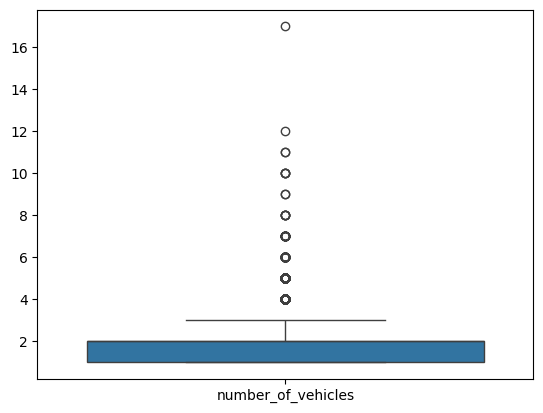

In [18]:
import seaborn as sns

sns.boxplot(data=df[['number_of_vehicles']])

In [19]:
q99 = df['number_of_casualties'].quantile(.99)

df = df[
df['number_of_casualties'] <= q99
]

In [20]:
df['collision_index'].duplicated().sum()

0

<Axes: xlabel='collision_severity'>

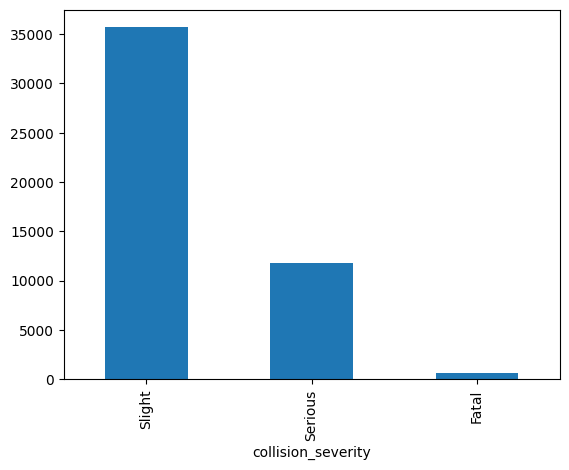

In [21]:
df['collision_severity'].value_counts().plot(
kind='bar'
)

<Axes: xlabel='day_of_week', ylabel='hour'>

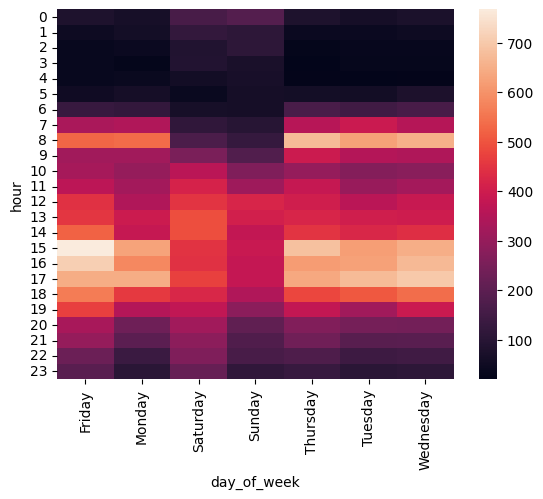

In [22]:
pivot = pd.crosstab(
df.hour,
df.day_of_week
)

sns.heatmap(pivot)

<Axes: xlabel='weather_conditions'>

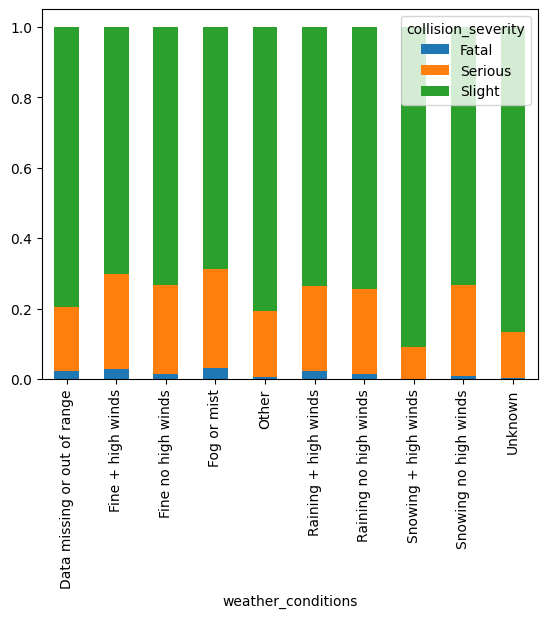

In [23]:
pd.crosstab(
df.weather_conditions,
df.collision_severity,
normalize='index'
).plot(kind='bar', stacked=True)

<Axes: xlabel='speed_limit', ylabel='number_of_casualties'>

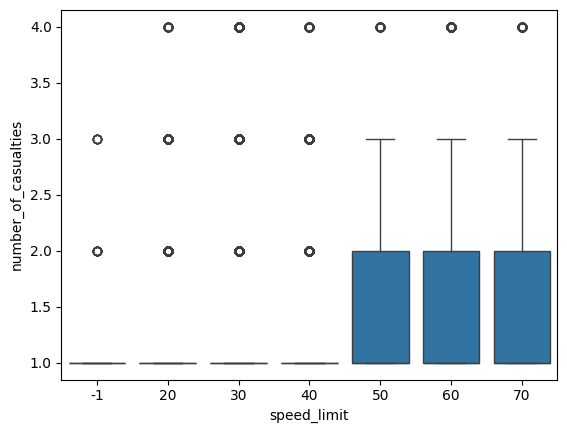

In [24]:
sns.boxplot(
x='speed_limit',
y='number_of_casualties',
data=df
)

In [25]:
pd.crosstab(
df.urban_or_rural_area,
df.collision_severity
)

collision_severity,Fatal,Serious,Slight
urban_or_rural_area,,,
Rural,436,4512,11072
Unallocated,0,0,3
Urban,238,7321,24619


<Axes: xlabel='light_conditions', ylabel='road_surface_conditions'>

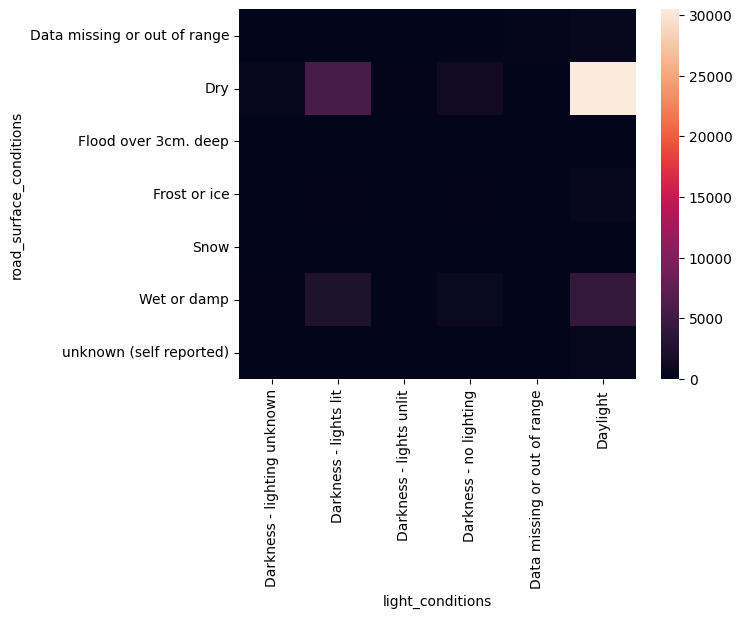

In [26]:
pivot = pd.crosstab(
df.road_surface_conditions,
df.light_conditions
)

sns.heatmap(pivot)

In [27]:
df.local_authority_district.value_counts().head(15)

local_authority_district
Code deprecated    48201
Name: count, dtype: int64

<Axes: >

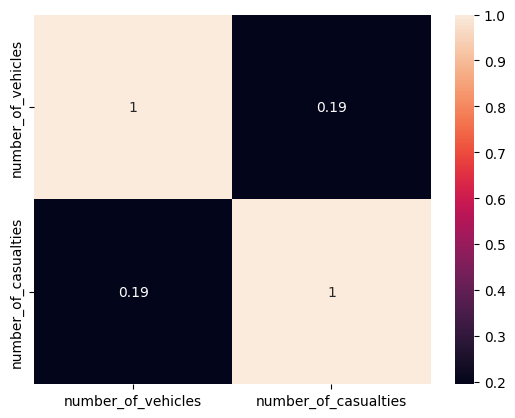

In [28]:
num_cols = [
'number_of_vehicles',
'number_of_casualties'
]

sns.heatmap(
df[num_cols].corr(),
annot=True
)

In [29]:
df["high_risk"] = (
(df["collision_severity"]=="Fatal") |
(df["collision_severity"]=="Serious")
)

In [30]:
df["wet_dark"] = (
(df["road_surface_conditions"]=="Wet or damp") &
(df["light_conditions"].str.contains("Dark"))
)

In [31]:
pca_cols = [
'speed_limit',
'number_of_vehicles',
'number_of_casualties'
]

In [32]:
from sklearn.preprocessing import LabelEncoder

for c in [
'weather_conditions',
'road_surface_conditions',
'light_conditions'
]:
    df[c+"_enc"] = LabelEncoder().fit_transform(
        df[c].astype(str)
    )

In [33]:
pca_cols += [
'weather_conditions_enc',
'road_surface_conditions_enc',
'light_conditions_enc'
]

In [34]:
from sklearn.preprocessing import StandardScaler

X = df[pca_cols].dropna()

X_scaled = StandardScaler().fit_transform(X)

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

In [36]:
print(
pca.explained_variance_ratio_
)

[0.26581475 0.22099773]


Text(0.5, 1.0, 'Collision PCA')

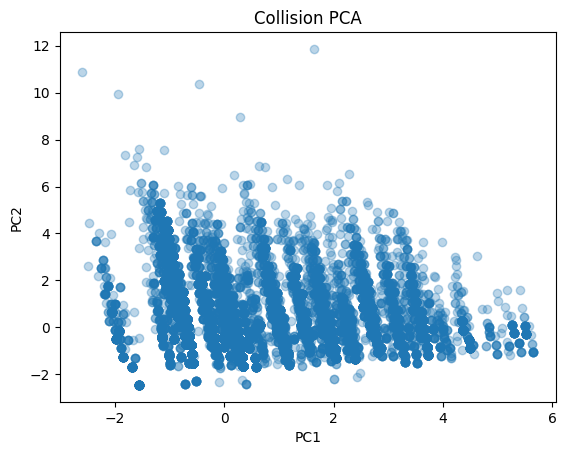

In [37]:
plt.scatter(
components[:,0],
components[:,1],
alpha=.3
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Collision PCA")

In [38]:
loadings = pd.DataFrame(
pca.components_.T,
columns=['PC1','PC2'],
index=pca_cols
)

print(loadings)

                                  PC1       PC2
speed_limit                 -0.032943  0.545896
number_of_vehicles          -0.087520  0.533185
number_of_casualties        -0.044711  0.627852
weather_conditions_enc       0.642210  0.035573
road_surface_conditions_enc  0.661585  0.137801
light_conditions_enc        -0.372997  0.057083


<Axes: >

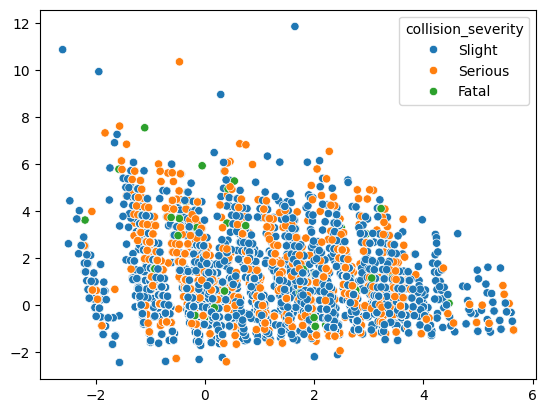

In [39]:
severity_map = df.loc[X.index,'collision_severity']

sns.scatterplot(
x=components[:,0],
y=components[:,1],
hue=severity_map
)

In [40]:
final_col=df
cols_2= [
'weather_conditions_enc',
'road_surface_conditions_enc',
'light_conditions_enc'
]
final_col = final_col.drop(columns=cols_2)

In [41]:
final_col.to_csv("refined_collisions.csv", index=False)

In [42]:
df.groupby(["urban_or_rural_area","collision_severity"])["collision_severity"].count().reset_index(name='collisions')

,urban_or_rural_area,collision_severity,collisions
0,Rural,Fatal,436
1,Rural,Serious,4512
2,Rural,Slight,11072
3,Unallocated,Slight,3
4,Urban,Fatal,238
5,Urban,Serious,7321
6,Urban,Slight,24619


In [43]:
df.groupby(["high_risk","collision_severity"])["number_of_casualties"].count().reset_index(name='collisions')

,high_risk,collision_severity,collisions
0,False,Slight,35694
1,True,Fatal,674
2,True,Serious,11833


In [46]:
df.groupby(["wet_dark","high_risk"])["number_of_casualties"].sum().reset_index(name='number_of_casualties')

,wet_dark,high_risk,number_of_casualties
0,False,False,39978
1,False,True,14809
2,True,False,3109
3,True,True,1372
